BANDITA JAISWAR
2419299

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning]/Copy of Copy of devnagari digit.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [3]:
import os
os.listdir("/content/dataset")

['DevanagariHandwrittenDigitDataset']

In [4]:
for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/DevanagariHandwrittenDigitDataset
/content/dataset/DevanagariHandwrittenDigitDataset/Test
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_0
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_3
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_9
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_1
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_2
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_6
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_7
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_4
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_8
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_5
/content/dataset/DevanagariHandwrittenDigitDataset/Train
/content/dataset/DevanagariHandwrittenDigitDataset/Train/digit_0
/content/dataset/DevanagariHandwrittenDigitDataset/Train/digit_3
/content/dataset/DevanagariHandwrittenDigitDatase

In [5]:
train_dir = "/content/dataset/devnagari-dataset/Train"
test_dir = "/content/dataset/devnagari-dataset/Test/"

In [7]:
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

# image size
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")   # grayscale
            img = img.resize((28, 28))               # resize
            img = np.array(img) / 255.0              # normalize

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

In [9]:
for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/DevanagariHandwrittenDigitDataset
/content/dataset/DevanagariHandwrittenDigitDataset/Test
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_0
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_3
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_9
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_1
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_2
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_6
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_7
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_4
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_8
/content/dataset/DevanagariHandwrittenDigitDataset/Test/digit_5
/content/dataset/DevanagariHandwrittenDigitDataset/Train
/content/dataset/DevanagariHandwrittenDigitDataset/Train/digit_0
/content/dataset/DevanagariHandwrittenDigitDataset/Train/digit_3
/content/dataset/DevanagariHandwrittenDigitDatase

In [10]:
train_dir = "/content/dataset/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/dataset/DevanagariHandwrittenDigitDataset/Test"

In [11]:
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

In [12]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [13]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [14]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(17000, 28, 28, 1) (17000, 10)
(3000, 28, 28, 1) (3000, 10)


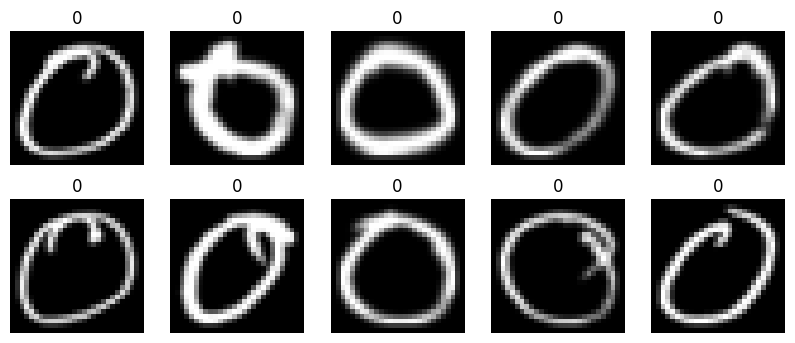

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(np.argmax(y_train[i]))
    plt.axis('off')

plt.show()

In [16]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(28,28,1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),
    keras.layers.Dense(10, activation='softmax')
])

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4231 - loss: 1.6517 - val_accuracy: 0.0000e+00 - val_loss: 7.2987
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8143 - loss: 0.5763 - val_accuracy: 0.0000e+00 - val_loss: 8.2089
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8971 - loss: 0.3116 - val_accuracy: 0.0000e+00 - val_loss: 8.9198
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9424 - loss: 0.2009 - val_accuracy: 0.0000e+00 - val_loss: 9.1920
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9594 - loss: 0.1441 - val_accuracy: 0.0000e+00 - val_loss: 9.6767
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9665 - loss: 0.1155 - val_accuracy: 0.0000e+00 - val_loss: 9.7786
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9736 - loss: 0.0948 - val_accuracy: 0.0000e+00 - val_loss: 9.6714
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9776 - lo

In [19]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7773 - loss: 2.1378
Test Accuracy: 0.7773333191871643


In [20]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(28,28,1)),
    keras.layers.Flatten(),

    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),

    keras.layers.Dense(10, activation='softmax')
])

In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4720 - loss: 1.5915 - val_accuracy: 0.0000e+00 - val_loss: 7.1818
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8435 - loss: 0.5194 - val_accuracy: 0.0000e+00 - val_loss: 8.2541
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9249 - loss: 0.2725 - val_accuracy: 0.0000e+00 - val_loss: 8.8864
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9498 - loss: 0.1831 - val_accuracy: 0.0000e+00 - val_loss: 9.2721
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9596 - loss: 0.1414 - val_accuracy: 0.0000e+00 - val_loss: 9.6199
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9677 - loss: 0.1124 - val_accuracy: 0.0000e+00 - val_loss: 9.7156
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9750 - loss: 0.0905 - val_accuracy: 0.0000e+00 - val_loss: 9.8643
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9801 - lo

In [23]:
# Save
model.save("devnagari_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("devnagari_model.h5")

# Evaluate again
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7847 - loss: 2.4311
Loaded Model Accuracy: 0.7846666574478149


In [24]:
import numpy as np

predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: [0 0 0 0 0 0 0 0 0 0]
Actual: [0 0 0 0 0 0 0 0 0 0]


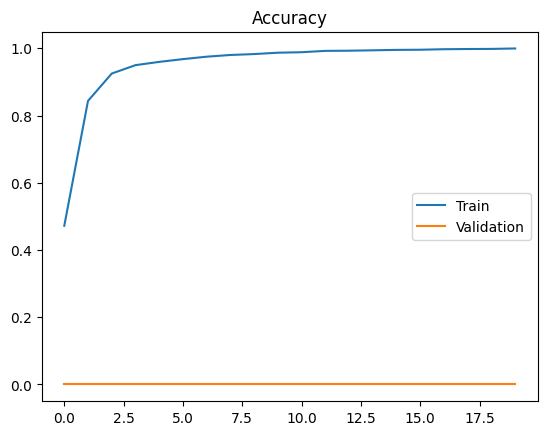

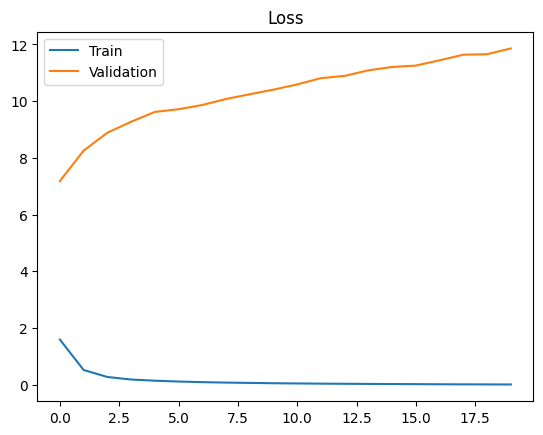

In [25]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()